In [110]:
from math import *
import numpy as np
from scipy.linalg import expm
from qutip import *
import random
from scipy import optimize
from datetime import datetime
import time
import pandas as pd
from scipy.linalg import fractional_matrix_power
from sklearn.feature_extraction.text import CountVectorizer
from scipy import linalg
from qutip import bloch
import matplotlib.pyplot as plt

In [111]:
# complex number
j = (-1)**0.5
 

# pauli matrix
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -j], [j, 0]])
sz = np.array([[1, 0], [0, -1]])
s0 = np.array([[1, 0], [0, 1]])

# Detunning Factor
d0 = 0.15
v0 = 0.02

In [112]:
def Rx(theta):
    return np.matrix([[cos(theta/2),     -1j*sin(theta/2)],
                    [-1j*sin(theta/2),     cos(theta/2)]])

def Rz(phi): # Rz는 사용하지 않음. 해밀토니안에 의한 회전으로만 컨트롤
    return np.matrix([[cos(phi/2)-1j*sin(phi/2),       0],
                     [0,                          cos(phi/2)+1j*sin(phi/2)]])

In [113]:
def unitary(dt, choice) :
    choice_list = [0,1,-1] # x-rotiation 방향 선택
    Ham = (d0*sz+v0*choice_list[choice]*sx)
    eigvals = np.linalg.eigh(Ham)[0]
    eigvecs = 1*np.linalg.eigh(Ham)[1]
    E = np.diag(eigvals)
    U_H = eigvecs.conj().T
    U_e = U_H.conj().T @ expm(-j*E*dt) @ U_H
    return U_e

In [114]:
def state_fidelity(rho_1, rho_2): #fidelity
        if np.shape(rho_1) != np.shape(rho_2):
            print("Dimensions of two states do not match.")
            return 0
        else:
            sqrt_rho_1 = fractional_matrix_power(rho_1, 1 / 2)
            fidelity = np.trace(fractional_matrix_power(sqrt_rho_1 @ rho_2 @ sqrt_rho_1, 1 / 2)) ** 2
            return np.real(fidelity)

In [115]:
init_wave = np.array([[1],[0]])
irho_init = np.kron(init_wave,init_wave.conj().T)

In [116]:
target_theta, target_phi , dt , combi = 3.042102479, 1.896262805 , 10.41151417 ,	[1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]
print(type(combi))
target_U = Rz(target_phi) @ Rx(target_theta)
irho_target = target_U @ irho_init @target_U.conj().T

<class 'list'>


In [117]:
temp = combi.copy()

In [118]:
combination = []
print(type(combi))
print(combination,combi)

dt = dt/1

<class 'list'>
[] [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]


In [119]:
for i in range(len(combi)):
    for j in range(3):
        combination.append(combi[i])

combi = combination.copy()

[[  2.39558496 -36.06517061]
 [-36.06517061 543.37314418]]
[[ 0.14508282 -1.54095293]
 [-1.54095293 23.25937678]]
[-0.44713158812718945, 0.0, -2.3534869109539205]
[[  2.39558496  36.06517061]
 [ 36.06517061 543.37314418]]
[[ 0.14508282  1.54095293]
 [ 1.54095293 23.25937678]]
[167.65317728665434, -7.888609052210118e-31, -1263.1058034718153]
[[  2.39558496 -36.06517061]
 [-36.06517061 543.37314418]]
[[ 0.14508282 -1.54095293]
 [-1.54095293 23.25937678]]
[-89979.15073756217, 0.0, -677364.1351648378]
[[  2.39558496  36.06517061]
 [ 36.06517061 543.37314418]]
[[ 0.14508282  1.54095293]
 [ 1.54095293 23.25937678]]
[48252932.05643567, 0.0, -363249198.18896395]
[[  2.39558496 -36.06517061]
 [-36.06517061 543.37314418]]
[[ 0.14508282 -1.54095293]
 [-1.54095293 23.25937678]]
[-25876538214.21882, 1.0587911840678754e-22, -194799182795.25336]
[[  2.39558496  36.06517061]
 [ 36.06517061 543.37314418]]
[[ 0.14508282  1.54095293]
 [ 1.54095293 23.25937678]]
[13876778043296.898, 5.421010862427522e-20,

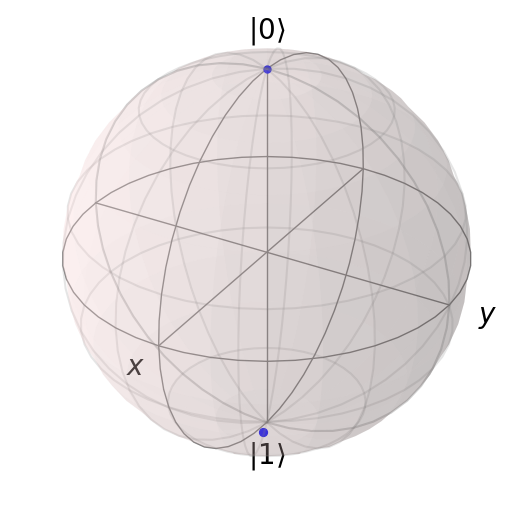

In [120]:

b = Bloch()
irho_mid = np.matrix(irho_init)
#irho_mid = (irho_init)
b.add_points([0,0,1],'m')
for i in temp:
    instant_U = unitary(dt,i)
    print((instant_U @ instant_U.conj().T))
    print(instant_U)
    irho_mid = (instant_U @ irho_mid @ instant_U.conj().T)
    point = [np.trace(irho_mid*sx).real,
             np.trace(irho_mid*sy).real,
             np.trace(irho_mid*sz).real]
    b.add_points(point,'m')
    print(point)

irho_mid = np.array(irho_mid)
print(1 - state_fidelity(irho_target,irho_mid))
point = [np.trace(irho_target*sx).real,
         np.trace(irho_target*sy).real,
         np.trace(irho_target*sz).real]
print(type(irho_target),"\n",point)
b.add_points(point,'r')
b.point_marker = ['o']
b.show()
